# Level 2: NumPy, Vectorization, Floating Point Errors, and Numerical Reliability 

**Project Title:** HydroSense-Kenya

### Imports and Setups

In [41]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('../src'))
from simulation import calculate_et
from data_cleaning import aggregate_daily_weather

# Loading datasets
weather = pd.read_csv("../data/raw/weather_daily.csv", na_values=["NA", ""])
soil = pd.read_csv("../data/raw/soil_sensor_data.csv", na_values=["NA", ""])
params = pd.read_csv("../data/raw/crop_zone_parameters.csv", na_values=["NA", ""])


# Aggregating data to daily level
weather = aggregate_daily_weather(weather)
weather.head()
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            31 non-null     object 
 1   rainfall_mm     31 non-null     float64
 2   temp_c          31 non-null     float64
 3   humidity_pct    31 non-null     float64
 4   wind_speed_mps  31 non-null     float64
 5   solar_index     31 non-null     int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 1.6+ KB


In [31]:
a = 0.1
b = 0.2
print(f"0.1 + 0.2 == 0.3: {a + b == 0.3}")
print(f"Actual value: {a + b:.18f}")

0.1 + 0.2 == 0.3: False
Actual value: 0.300000000000000044


## 2. Vectorization vs. Loops
We compare the performance of standard Python loops against NumPy vectorization for computing Evapotranspiration.

### a). Loop-Based Timing

In [32]:
# Loop based timing
loop_results = []
start = time.perf_counter()
for _, row in weather.iterrows():
    et = calculate_et(
        row["temp_c"],
        row["wind_speed_mps"],
        row["solar_index"],
        row["humidity_pct"]
    )
    loop_results.append(et)
end = time.perf_counter()
loop_time = end - start
print(f"Duration of loop-based calculation: {loop_time:.4f} seconds")
weather["et_loop"] = loop_results
weather[["date", "et_loop"]].head()

Duration of loop-based calculation: 0.0068 seconds


,date,et_loop
0,2026-03-01,0.680632
1,2026-03-02,0.820447
2,2026-03-03,0.872495
3,2026-03-04,0.449505
4,2026-03-05,0.418811


### b). Vectorized Timing

In [33]:
# Vectorized timing
temp = weather["temp_c"].to_numpy()
humidity = weather["humidity_pct"].to_numpy()
wind = weather["wind_speed_mps"].to_numpy()
solar = weather["solar_index"].to_numpy()

start = time.perf_counter()
et_vectorized = np.maximum(
    0,
    0.12 * temp + 0.35 * wind + 2.4 * solar - 0.025 * humidity
)
end = time.perf_counter()

vectorized_time = end - start
print(f"Duration of vectorized callculation: {vectorized_time:.4f} seconds")
weather["et_vectorized"] = et_vectorized
weather[["date", "et_vectorized"]].head()

Duration of vectorized callculation: 0.0004 seconds


,date,et_vectorized
0,2026-03-01,0.680632
1,2026-03-02,0.820447
2,2026-03-03,0.872495
3,2026-03-04,0.449505
4,2026-03-05,0.418811


### Comparison

From the results, vvectorized calculation is faster than normal python loop calculation

In [34]:
timing_df = pd.DataFrame({
    "Method": ["Loop", "Vectorized"],
    "Execution Time (s)": [loop_time, vectorized_time]
})
print(f"Speedup: {loop_time/vectorized_time:.2f}x")
timing_df

Speedup: 17.21x


,Method,Execution Time (s)
0,Loop,0.006773
1,Vectorized,0.000393


## Floating Point Experiment

In [35]:
print(0.1 + 0.2)
print(0.3 == 0.1 + 0.2)

a = np.float64(0.1)
b = np.float64(0.2)

print(a + b)
print(repr(a + b))

0.30000000000000004
False
0.30000000000000004
np.float64(0.30000000000000004)


## Rounding and Truncation Error

In [36]:
true_value = 10 / 3
rounded = round(true_value, 2)
truncated = int(true_value * 100) / 100

print(true_value, rounded, truncated)

print(abs(true_value - rounded))
print(abs(true_value - truncated))

3.3333333333333335 3.33 3.33
0.0033333333333334103
0.0033333333333334103


## Error Propagation Experiment

In scientific computing, raw measurements are rarely perfect.

Our irrigation system depends on measurements like:

- temperature
- humidity
- wind speed~
- solar intensity

But in real life:

-   sensors have noise
-    instruments drift
-    readings may be rounded
-   communication systems may corrupt values slightly

To understand how these imperfections impact our model, I have **intentionally added noise to the temperature values**.  
This allows us to observe **how errors propagate through the system** and evaluate the robustness of our irrigation recommendations.

0    0.120624
1    0.031747
2    0.060378
3    0.030459
4    0.024763
Name: et_difference, dtype: float64


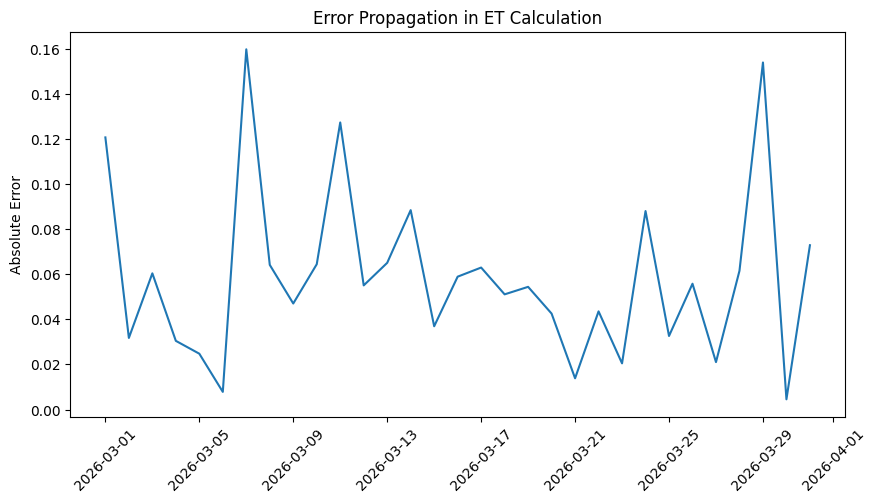

In [40]:
noise = np.random.normal(0, 0.5, size=len(temp))
temp_noisy = temp + noise

et_noisy = np.maximum(
    0,
    0.12 * temp_noisy + 0.35 * wind + 2.4 * solar - 0.025 * humidity
)

weather["et_difference"] = np.abs(et_vectorized - et_noisy)
print(weather['et_difference'].head(5))
plt.figure(figsize=(10, 5))
plt.plot(weather["date"], weather["et_difference"])
plt.xticks(rotation=45)
plt.ylabel("Absolute Error")
plt.title("Error Propagation in ET Calculation")
plt.show()

## Why Numerical Reliability Matters in Scientific Computing
Scientific computing requires not only producing numerical results but ensuring those results are reliable enough for real-world decisions. In this project, small simulated errors in temperature measurements caused noticeable differences in evapotranspiration values, showing how uncertainty in input data propagates through calculations. Floating-point arithmetic can also introduce small precision errors that may accumulate over repeated computations. In irrigation systems, such numerical inaccuracies could lead to over-irrigation, water wastage, or crop moisture stress. Therefore, validating computations, understanding numerical limitations, and testing model sensitivity are essential parts of building trustworthy scientific models.

## Conclusion
This notebook compared loop-based and vectorized computation for evapotranspiration and showed that NumPy is more efficient for scientific tasks. Floating-point and error propagation experiments demonstrated how small numerical inaccuracies can affect final results. Overall, reliable computation is essential for accurate irrigation decision-making in HydroSense-Kenya.